In [1]:
!pip install pretrainedmodels

    100% |████████████████████████████████| 61kB 4.6MB/s 
  Stored in directory: /tmp/.cache/pip/wheels/69/df/63/62583c096289713f22db605aa2334de5b591d59861a02c2ecd
Successfully built pretrainedmodels
You are using pip version 19.0.3, however version 19.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.


In [2]:
import pretrainedmodels

In [3]:
import os

In [4]:
os.listdir("../input/train/train")

['cbsd', 'cmd', 'healthy', 'cbb', 'cgm']

In [5]:
os.listdir("../input/train/train/cgm")[:10]

['train-cgm-612.jpg',
 'train-cgm-528.jpg',
 'train-cgm-436.jpg',
 'train-cgm-105.jpg',
 'train-cgm-531.jpg',
 'train-cgm-235.jpg',
 'train-cgm-250.jpg',
 'train-cgm-107.jpg',
 'train-cgm-394.jpg',
 'train-cgm-450.jpg']

In [6]:
os.listdir("../input/test/test/0")[:10]

['test-img-3488.jpg',
 'test-img-2937.jpg',
 'test-img-2068.jpg',
 'test-img-1611.jpg',
 'test-img-1088.jpg',
 'test-img-3042.jpg',
 'test-img-201.jpg',
 'test-img-1118.jpg',
 'test-img-623.jpg',
 'test-img-1250.jpg']

In [7]:
from fastai import *
from fastai.vision import *

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import auc,roc_curve

from math import floor

In [8]:
train_path = "../input/train/train"
test_path = "../input/test/test/0"

In [9]:
def get_labels(file_path): 
    dir_name = os.path.dirname(file_path)
    split_dir_name = dir_name.split("/")
    dir_levels = len(split_dir_name)
    label  = split_dir_name[dir_levels - 1]
    return(label)

In [10]:
get_labels("../input/train/train/cgm/train-cgm-528.jpg")

'cgm'

In [11]:
from glob import glob
imagePatches = glob("../input/train/train/*/*.*", recursive=True)
imagePatches[0:10]

['../input/train/train/cbsd/train-cbsd-145.jpg',
 '../input/train/train/cbsd/train-cbsd-449.jpg',
 '../input/train/train/cbsd/train-cbsd-454.jpg',
 '../input/train/train/cbsd/train-cbsd-577.jpg',
 '../input/train/train/cbsd/train-cbsd-194.jpg',
 '../input/train/train/cbsd/train-cbsd-785.jpg',
 '../input/train/train/cbsd/train-cbsd-58.jpg',
 '../input/train/train/cbsd/train-cbsd-1381.jpg',
 '../input/train/train/cbsd/train-cbsd-1393.jpg',
 '../input/train/train/cbsd/train-cbsd-759.jpg']

In [12]:
path=""
tfms = get_transforms() 

In [13]:
data = ImageDataBunch.from_name_func(path, imagePatches, label_func=get_labels,  size=500, 
                                     bs=20,num_workers=2,test = test_path,ds_tfms=tfms
                                  ).normalize(imagenet_stats)

In [14]:
type(data)

fastai.vision.data.ImageDataBunch

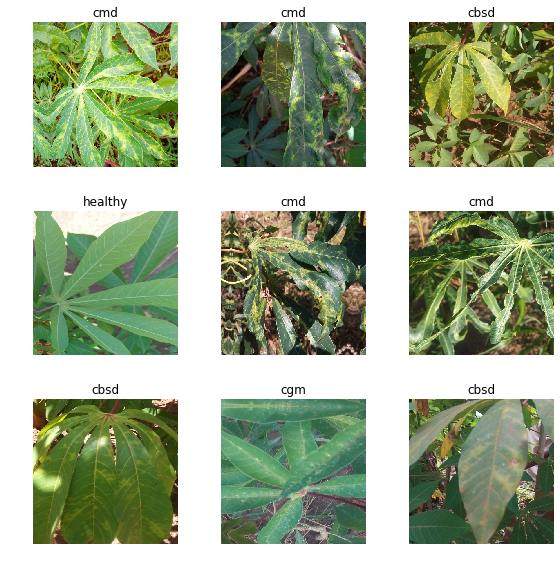

In [15]:
data.show_batch(rows=3, figsize=(8,8))

In [16]:
def se_resnext50_32x4d(pretrained=False):
    pretrained = 'imagenet' if pretrained else None
    model = pretrainedmodels.se_resnext50_32x4d(pretrained=pretrained)
    return model

In [17]:
learner = cnn_learner(data, se_resnext50_32x4d, pretrained=True,
                   cut=-2, split_on=lambda m: (m[0][3], m[1]),metrics = [accuracy])

Downloading: "http://data.lip6.fr/cadene/pretrainedmodels/se_resnext50_32x4d-a260b3a4.pth" to /tmp/.torch/models/se_resnext50_32x4d-a260b3a4.pth
110559176it [05:10, 355552.44it/s]


LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


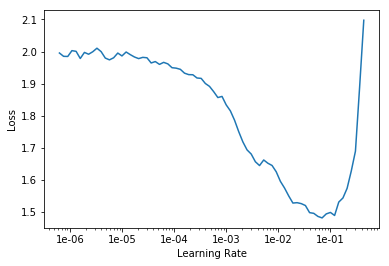

In [18]:
learner.lr_find()
learner.recorder.plot()

In [19]:
lr=1e-1
learner.fit_one_cycle(1, lr)

epoch,train_loss,valid_loss,accuracy,time
0,1.945451,4.883545,0.588859,04:48


In [20]:
learner.save('model-1')

In [21]:
learner.unfreeze()

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


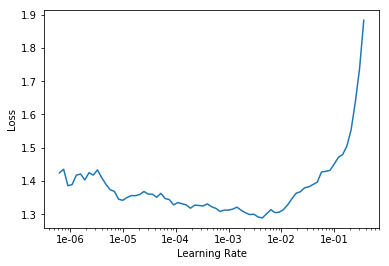

In [22]:
learner.lr_find()
learner.recorder.plot()

In [23]:
learner.freeze_to(-2)

LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


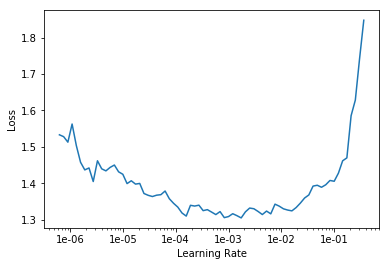

In [24]:
learner.lr_find()
learner.recorder.plot()

In [25]:
learner.fit_one_cycle(80, 1e-5)

epoch,train_loss,valid_loss,accuracy,time
0,1.358220,17.247034,0.597701,04:41
1,1.352461,2.229143,0.583554,04:42
2,1.339970,3.229409,0.593280,04:40
3,1.362047,3.775995,0.587975,04:38
4,1.345992,3.848962,0.583554,04:35
5,1.281230,2.655535,0.603006,04:32
6,1.231449,2.995032,0.615385,04:30
7,1.245531,2.874996,0.628647,04:33
8,1.216014,26.006056,0.627763,04:32
9,1.196371,4.740907,0.633068,04:31


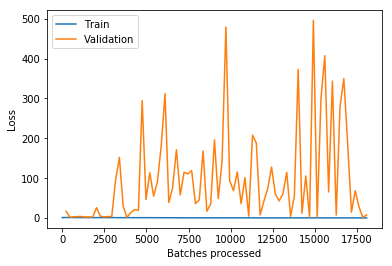

In [26]:
learner.recorder.plot_losses()

In [27]:
learner.validate()

[7.9510365, tensor(0.8099)]

In [28]:
interp = ClassificationInterpretation.from_learner(learner)

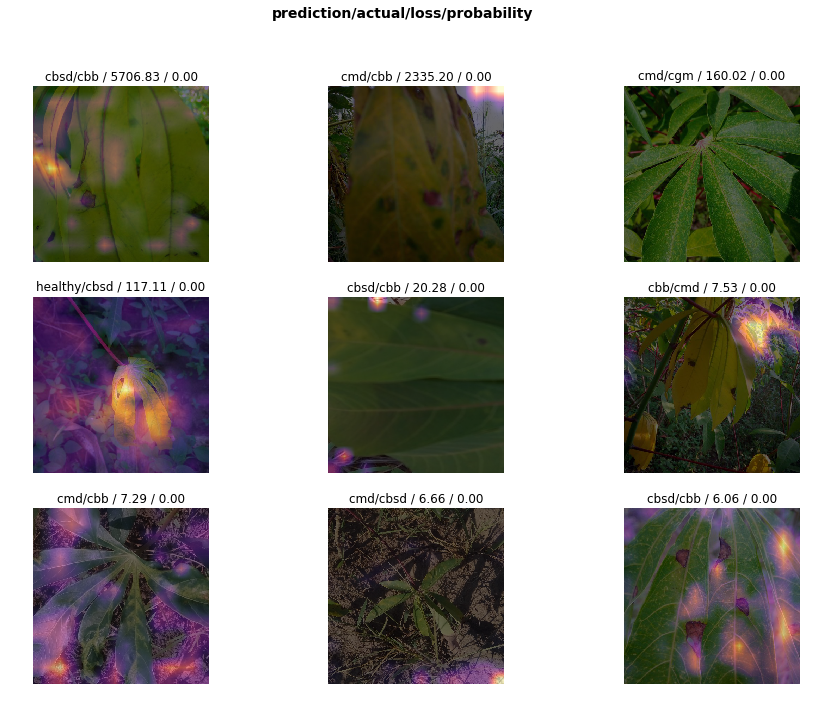

In [29]:
interp.plot_top_losses(9, figsize=(15,11))

In [30]:
interp.most_confused(min_val=2)

[('cbb', 'cbsd', 37),
 ('cgm', 'cmd', 31),
 ('cbsd', 'cmd', 27),
 ('cbsd', 'cbb', 20),
 ('cmd', 'cgm', 16),
 ('cbsd', 'cgm', 12),
 ('cgm', 'cbsd', 12),
 ('healthy', 'cmd', 12),
 ('healthy', 'cbsd', 10),
 ('cmd', 'cbsd', 9),
 ('cbb', 'cmd', 8),
 ('cbsd', 'healthy', 4),
 ('healthy', 'cbb', 3),
 ('healthy', 'cgm', 3),
 ('cbb', 'cgm', 2),
 ('cbb', 'healthy', 2),
 ('cgm', 'cbb', 2),
 ('cgm', 'healthy', 2),
 ('cmd', 'cbb', 2)]

In [31]:
preds,y = learner.TTA(ds_type=DatasetType.Test)

In [32]:
len(preds)

3774

In [33]:
len(os.listdir(test_path))

3774

In [34]:
SAMPLE_SUB = '../input/sample_submission_file.csv'
sample_df = pd.read_csv(SAMPLE_SUB)

In [35]:
sample_df.head()

,Category,Id
0,cbsd,test-img-0.jpg
1,cmd,test-img-1.jpg
2,cbb,test-img-2.jpg
3,cmd,test-img-3.jpg
4,cbsd,test-img-4.jpg


In [36]:
predictions = preds.numpy()

In [37]:
class_preds = np.argmax(predictions, axis=1)

In [38]:
for c, i in learner.data.train_ds.y.c2i.items():
    print(c,i)

cbb 0
cbsd 1
cgm 2
cmd 3
healthy 4


In [39]:
categories = ['cbb','cbsd','cgm','cmd','healthy']

def map_to_categories(predictions):
    return(categories[predictions])

categories_preds = list(map(map_to_categories,class_preds))

In [40]:
filenames = list(map(os.path.basename,os.listdir(test_path)))

In [41]:
df_sub = pd.DataFrame({'Category':categories_preds,'Id':filenames})

In [42]:
df_sub.head()

,Category,Id
0,cmd,test-img-3488.jpg
1,cbb,test-img-2937.jpg
2,cmd,test-img-2068.jpg
3,cgm,test-img-1611.jpg
4,cmd,test-img-1088.jpg


In [43]:
# Export to csv
df_sub.to_csv('submission_categories.csv', header=True, index=False)